# 📊 Insurance Charges — Regression Models
> **Goal:** Predict medical insurance charges using various regression algorithms and ensemble methods.  
> **Dataset:** `insurance.csv` — contains demographic and health features (age, sex, BMI, children, smoker, region) with `charges` as the target.

---


## 1. 📦 Libraries & Imports
All required libraries for data manipulation, visualisation, preprocessing, and modelling are loaded here.


In [2]:
#pip install xgboost lightgbm catboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, BaggingRegressor,
    AdaBoostRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor,
    VotingRegressor, StackingRegressor
)

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110


---
## 2. 📂 Load Dataset


In [3]:
df = pd.read_csv('insurance.csv')
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.92400
1,18.0,male,33.770,1.0,no,southeast,1725.55230
2,28.0,male,33.000,3.0,no,southeast,4449.46200
3,33.0,male,22.705,0.0,no,northwest,21984.47061
4,32.0,male,28.880,0.0,no,northwest,3866.85520


---
## 3. 🔍 Exploratory Data Analysis (EDA)

Before building any model, we explore the data to understand its structure, distributions, relationships and potential issues.


### 3.1 Dataset Shape & Info


In [4]:
print("Shape:", df.shape)
print()
df.info()


Shape: (1338, 7)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1296 non-null   float64
 1   sex       1329 non-null   object 
 2   bmi       1296 non-null   float64
 3   children  1314 non-null   float64
 4   smoker    1305 non-null   object 
 5   region    1054 non-null   object 
 6   charges   1314 non-null   float64
dtypes: float64(4), object(3)
memory usage: 73.3+ KB


### 3.2 Descriptive Statistics


In [5]:
df.describe()


,age,bmi,children,charges
count,1296.000000,1296.000000,1314.000000,1314.000000
mean,39.225309,30.655197,1.092846,13259.233168
std,14.034162,6.117612,1.205684,12136.291497
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4724.369462
50%,39.000000,30.380000,1.000000,9289.083100
75%,51.000000,34.600000,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### 3.3 Missing Values


In [6]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "✅ No missing values found.")


age          42
sex           9
bmi          42
children     24
smoker       33
region      284
charges      24
dtype: int64


### 3.4 Target Variable Distribution (`charges`)

The target is right-skewed — most people have moderate charges but a small group has very high costs (likely heavy smokers).


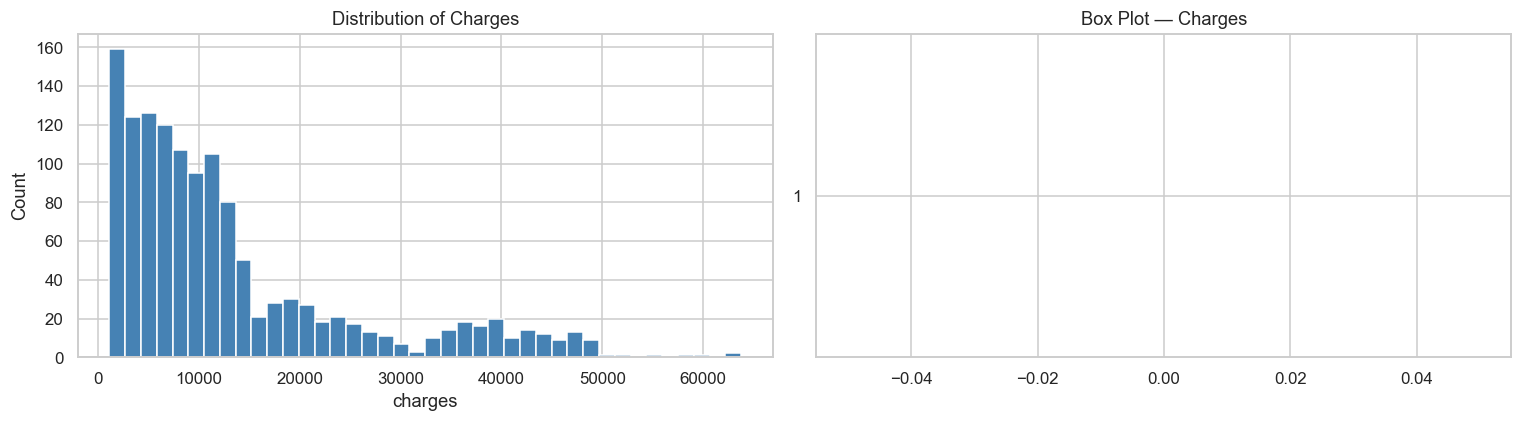

Skewness : 1.519
Kurtosis : 1.611


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Charges')
axes[0].set_xlabel('charges')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['charges'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Box Plot — Charges')

plt.tight_layout()
plt.show()

print(f"Skewness : {df['charges'].skew():.3f}")
print(f"Kurtosis : {df['charges'].kurt():.3f}")


### 3.5 Numerical Features Distribution


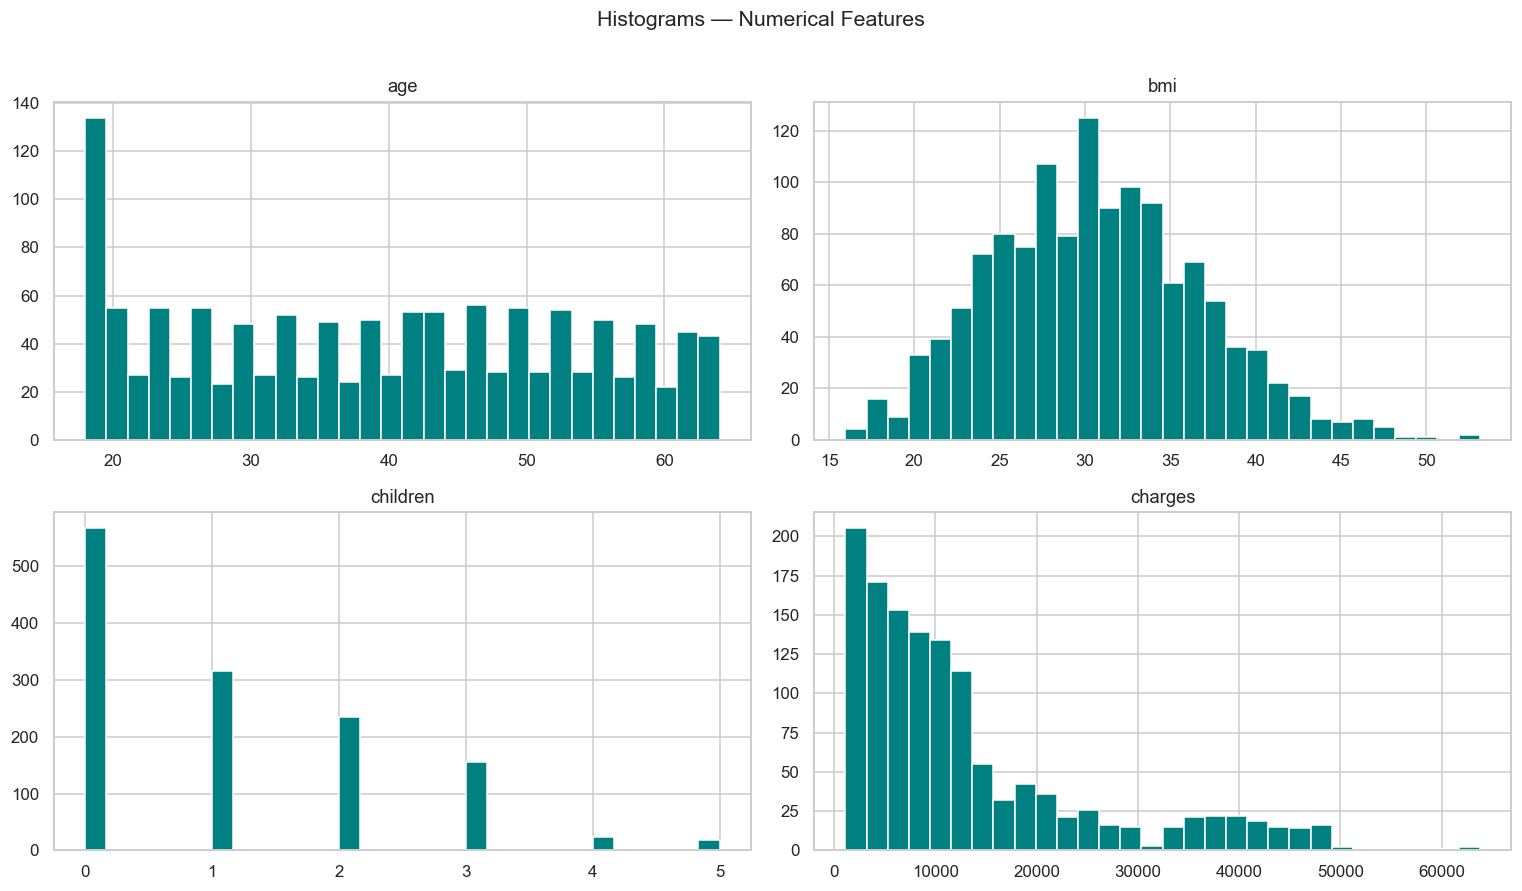

In [8]:
num_cols = ['age', 'bmi', 'children', 'charges']
df[num_cols].hist(bins=30, figsize=(14, 8), color='teal', edgecolor='white', layout=(2, 2))
plt.suptitle('Histograms — Numerical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### 3.6 Categorical Features Distribution


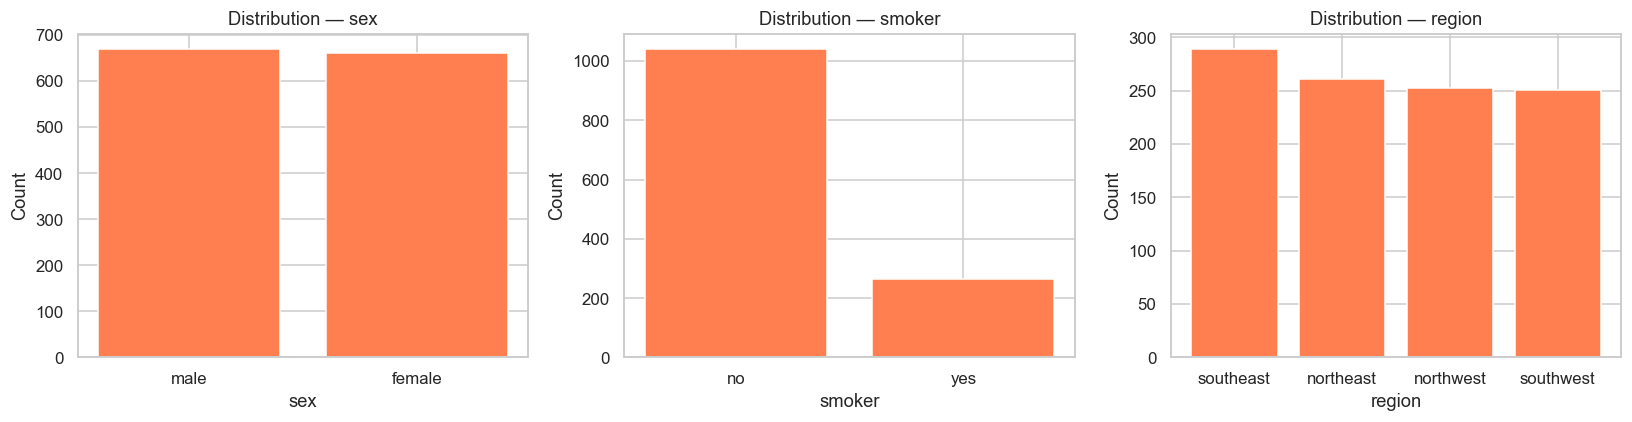

In [9]:
cat_cols = ['sex', 'smoker', 'region']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color='coral', edgecolor='white')
    ax.set_title(f'Distribution — {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


### 3.7 Charges by Categorical Features


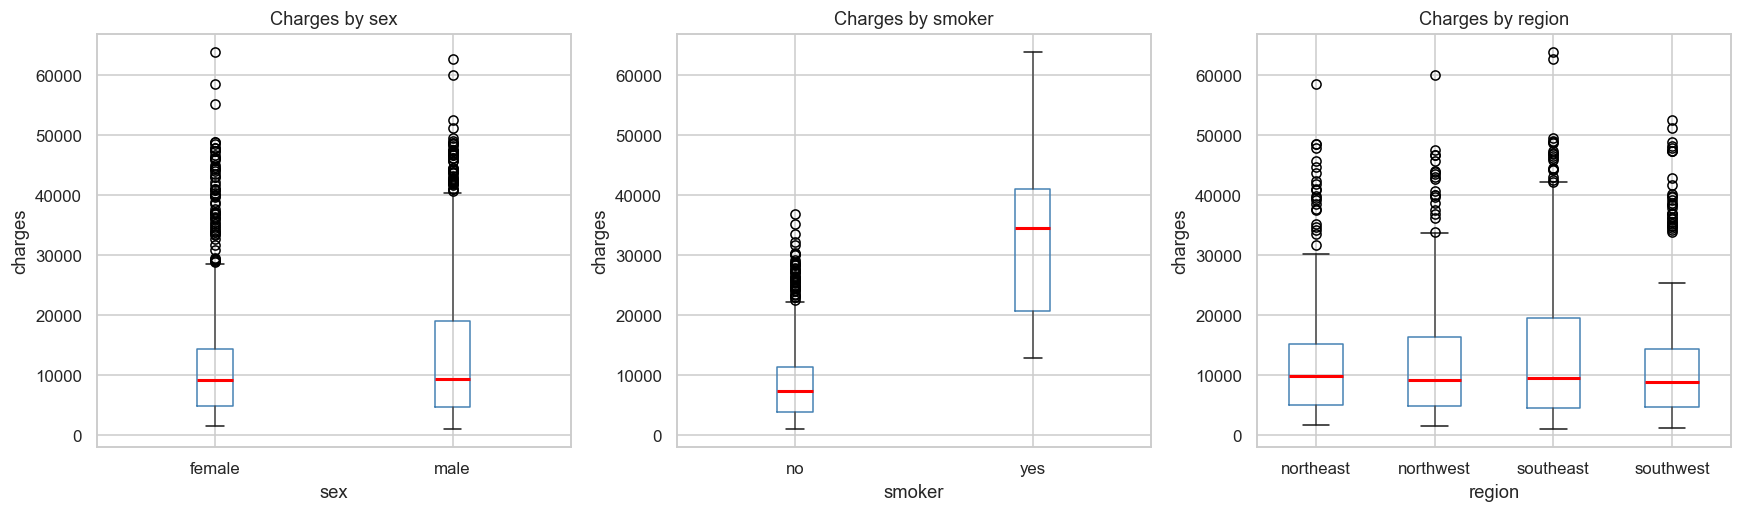

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, cat_cols):
    df.boxplot(column='charges', by=col, ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'Charges by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('charges')

plt.suptitle('')
plt.tight_layout()
plt.show()


### 3.8 Correlation Heatmap

After encoding, we inspect linear correlations. `smoker` is expected to be the strongest predictor.


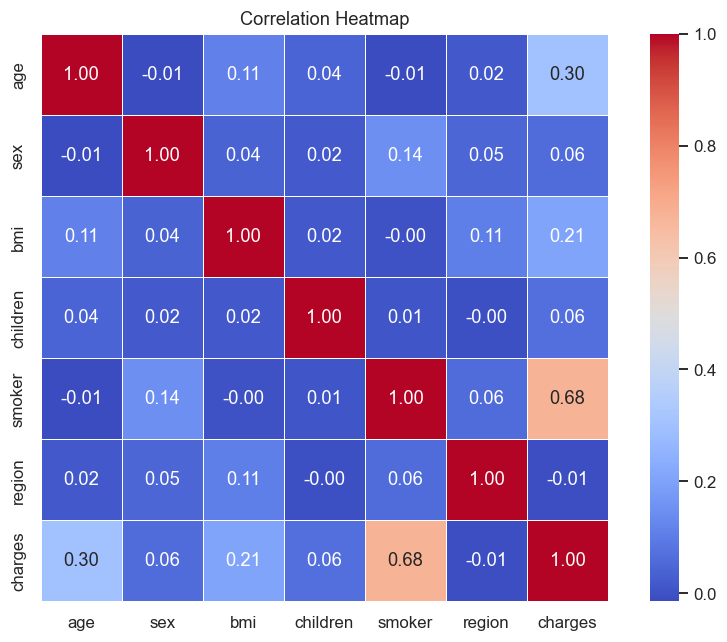

In [11]:
# Temporary encoded copy for correlation
df_enc = df.copy()
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df_enc[col] = le.fit_transform(df_enc[col])

plt.figure(figsize=(8, 6))
sns.heatmap(df_enc.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


### 3.9 Scatter Plots — Key Features vs Charges


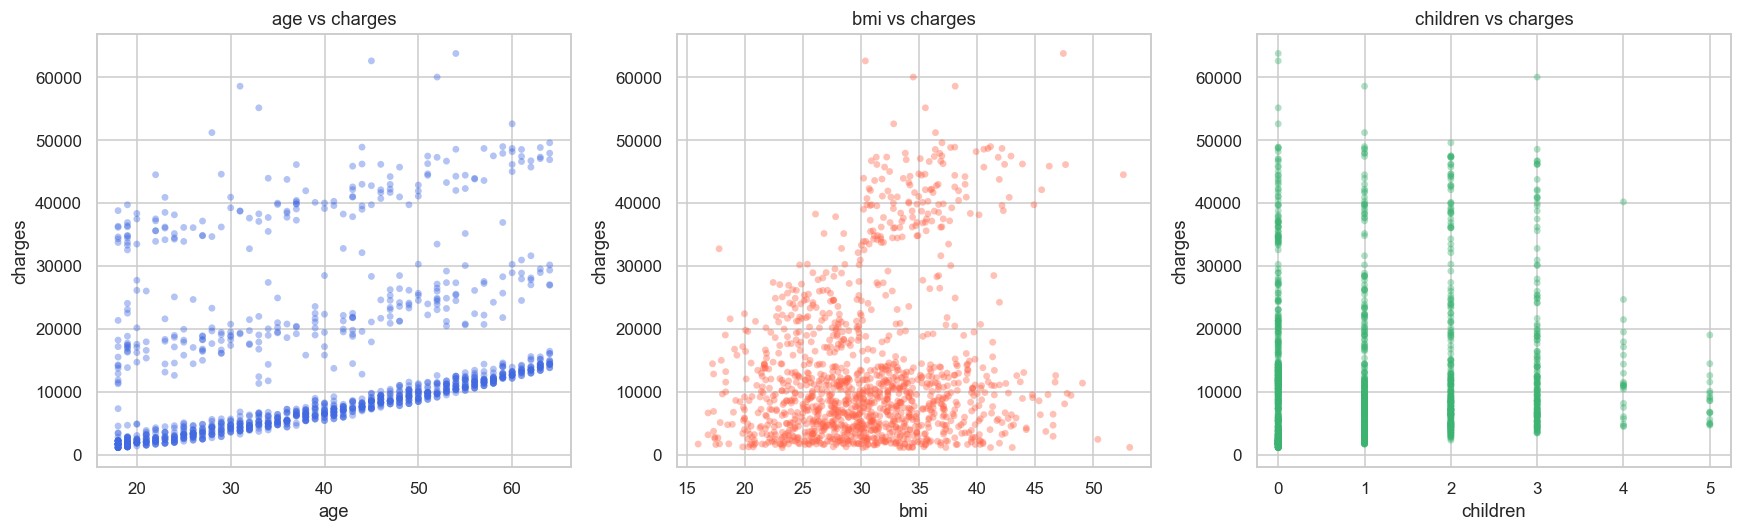

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
scatter_cols = ['age', 'bmi', 'children']
colors = ['royalblue', 'tomato', 'mediumseagreen']

for ax, col, c in zip(axes, scatter_cols, colors):
    ax.scatter(df[col], df['charges'], alpha=0.4, color=c, edgecolors='none', s=20)
    ax.set_xlabel(col)
    ax.set_ylabel('charges')
    ax.set_title(f'{col} vs charges')

plt.tight_layout()
plt.show()


### 3.10 Smoker Impact — Age vs Charges


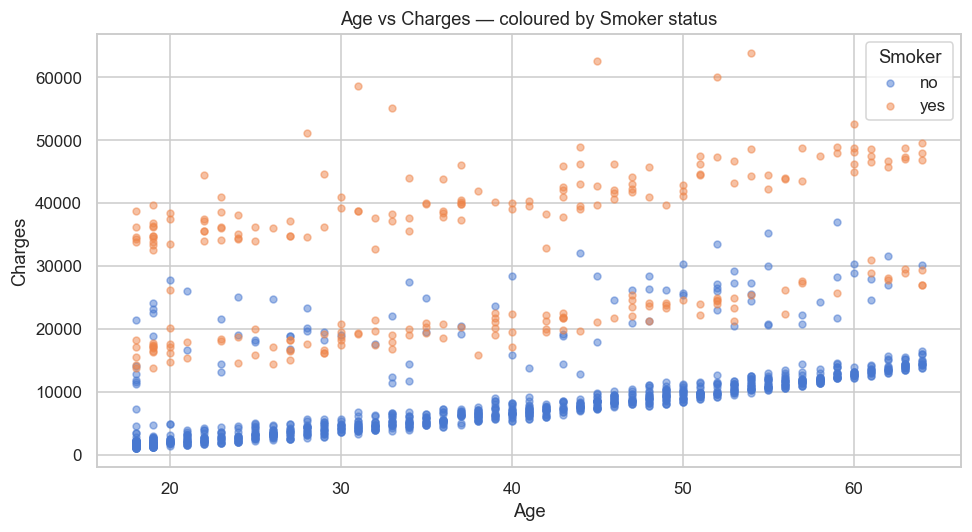

In [13]:
plt.figure(figsize=(9, 5))
for label, group in df.groupby('smoker'):
    plt.scatter(group['age'], group['charges'], alpha=0.5, label=label, s=20)
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Age vs Charges — coloured by Smoker status')
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()


---
## 4. 🧹 Data Preprocessing

### 4.1 Handle Missing Values


In [14]:
# Numerical: fill with mean
for col in ['age', 'bmi', 'children', 'charges']:
    df[col].fillna(df[col].mean(), inplace=True)

# Categorical: fill with mode
for col in ['sex', 'smoker', 'region']:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


C:\Users\roka\AppData\Local\Temp\ipykernel_14884\2369570869.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\roka\AppData\Local\Temp\ipykernel_14884\2369570869.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

### 4.2 Encode Categorical Variables


In [15]:
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df[col] = le.fit_transform(df[col])

df.head()


,age,sex,bmi,children,smoker,region,charges
0,19.0,0,27.900,0.0,1,3,16884.92400
1,18.0,1,33.770,1.0,0,2,1725.55230
2,28.0,1,33.000,3.0,0,2,4449.46200
3,33.0,1,22.705,0.0,0,1,21984.47061
4,32.0,1,28.880,0.0,0,1,3866.85520


### 4.3 Feature / Target Split


In [16]:
X = df.drop("charges", axis=1)
y = df["charges"]

print("Features shape:", X.shape)
print("Target shape  :", y.shape)


Features shape: (1338, 6)
Target shape  : (1338,)


### 4.4 Train / Test Split (80 / 20)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=100
)

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   |  y_test : {y_test.shape}")


X_train: (1070, 6)  |  y_train: (1070,)
X_test : (268, 6)   |  y_test : (268,)


### 4.5 Feature Scaling (MinMaxScaler)


In [18]:
my_scaler = MinMaxScaler(feature_range=(0, 1))
X_train = my_scaler.fit_transform(X_train)
X_test  = my_scaler.transform(X_test)


---
## 5. 🤖 Regression Models

### 5.1 Define Base Models


In [23]:
models = {
    "Linear Regression": LinearRegression(),
    "KNN":               KNeighborsRegressor(n_neighbors=5, metric='minkowski', p=1),
    "SVM":               SVR(kernel='linear', C=100, gamma=1),
    "Decision Tree":     DecisionTreeRegressor(criterion='squared_error', max_depth=10),
}


### 5.2 Evaluation Helper Function


In [22]:
def regression_metrics(model, X, y_actual):
    """Return MAE, MSE, RMSE, R² for a fitted model."""
    y_pred = model.predict(X)
    MAE  = mean_absolute_error(y_actual, y_pred)
    MSE  = mean_squared_error(y_actual, y_pred)
    RMSE = np.sqrt(MSE)
    R2   = r2_score(y_actual, y_pred)
    return MAE, MSE, RMSE, R2


### 5.3 Train & Evaluate Base Models


  0%|          | 0/4 [00:00<?, ?it/s]

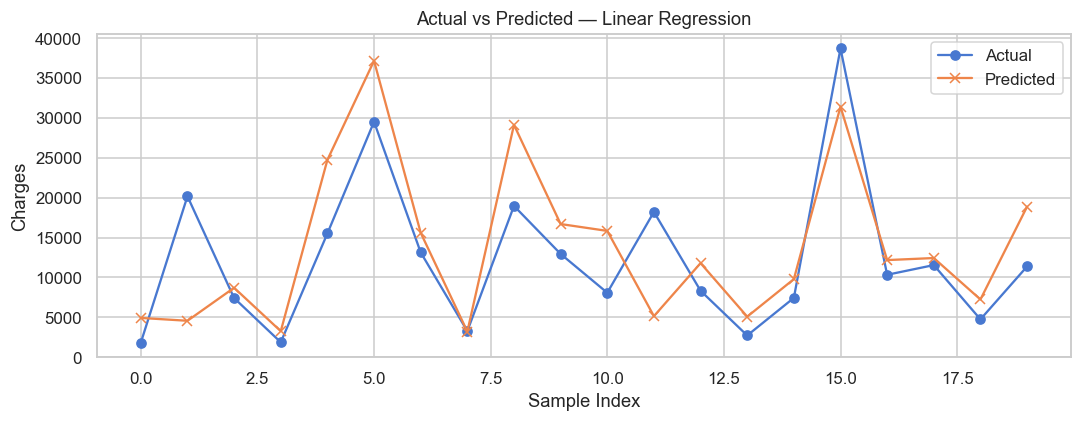

 25%|██▌       | 1/4 [00:00<00:01,  1.68it/s]

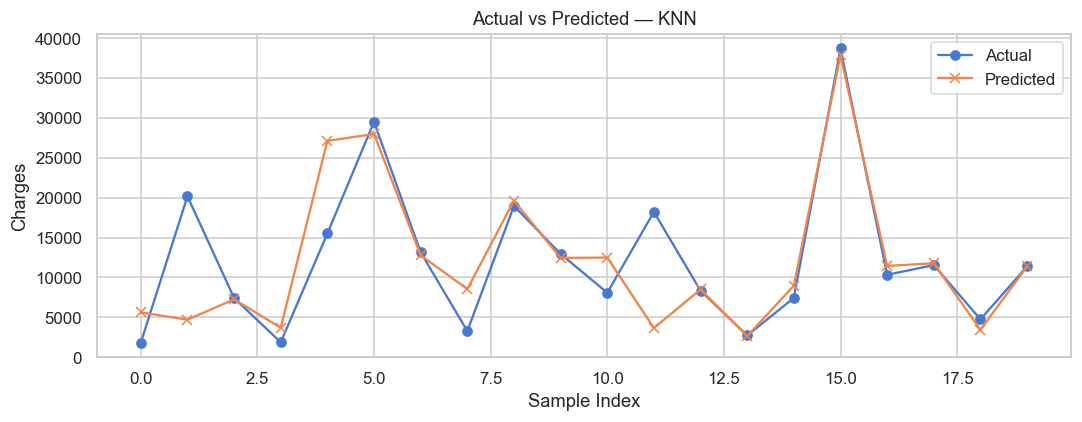

 50%|█████     | 2/4 [00:01<00:01,  1.81it/s]

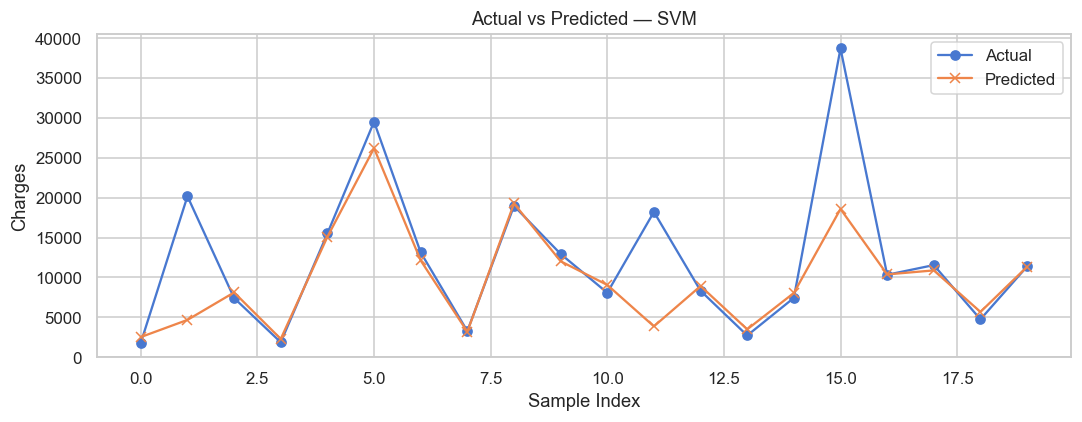

 75%|███████▌  | 3/4 [00:01<00:00,  1.62it/s]

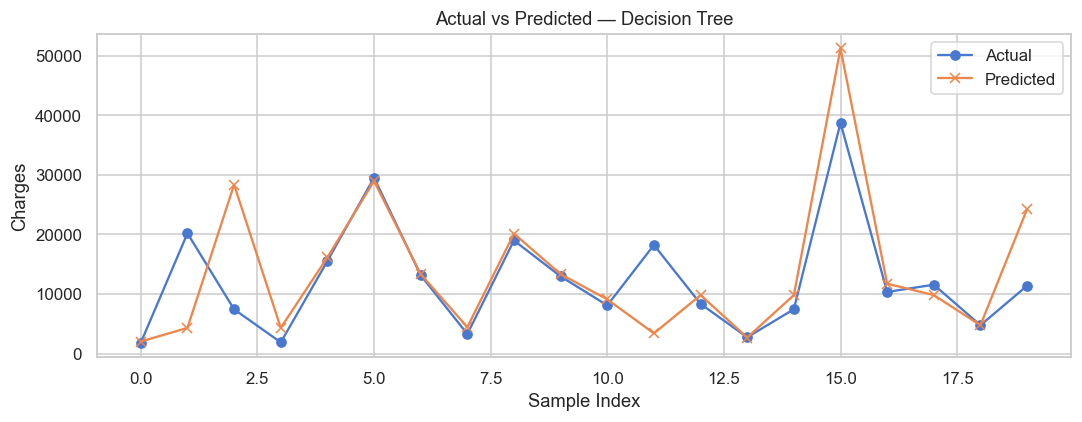

100%|██████████| 4/4 [00:02<00:00,  1.78it/s]


In [21]:
errors = {}

for model_name, model in tqdm(models.items()):
    model.fit(X_train, y_train)

    MAE_Train, MSE_Train, RMSE_Train, R_Train = regression_metrics(model, X_train, y_train)
    MAE_Test,  MSE_Test,  RMSE_Test,  R_Test  = regression_metrics(model, X_test,  y_test)

    errors[model_name] = {
        "MAE Train": MAE_Train, "MAE Test": MAE_Test,
        "MSE Train": MSE_Train, "MSE Test": MSE_Test,
        "RMSE Train": RMSE_Train, "RMSE Test": RMSE_Test,
        "R2 Train": R_Train,   "R2 Test": R_Test
    }

    # Actual vs Predicted — first 20 test samples
    y_test_plot = y_test.values[:20]
    y_pred_plot = model.predict(X_test[:20])

    plt.figure(figsize=(10, 4))
    plt.plot(range(20), y_test_plot, label='Actual', marker='o')
    plt.plot(range(20), y_pred_plot, label='Predicted', marker='x')
    plt.xlabel('Sample Index')
    plt.ylabel('Charges')
    plt.title(f'Actual vs Predicted — {model_name}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


---
## 6. 🗳️ Ensemble — Voting Regression

Three voting strategies are compared:
| Strategy | Description |
|---|---|
| **Simple Voting** | Equal-weight average of all base models |
| **Voting** | Same structure (alias for comparison) |
| **Weighted Voting** | LR × 2, KNN × 1, DT × 2 |


In [24]:
clf1 = LinearRegression()
clf2 = KNeighborsRegressor(n_neighbors=5)
clf3 = DecisionTreeRegressor(random_state=1)

model1 = VotingRegressor(estimators=[('lr', clf1), ('knn', clf2), ('dt', clf3)])
model2 = VotingRegressor(estimators=[('lr', clf1), ('knn', clf2), ('dt', clf3)])
model3 = VotingRegressor(estimators=[('lr', clf1), ('knn', clf2), ('dt', clf3)],
                         weights=[2, 1, 2])

model1.fit(X_train, y_train)
model2.fit(X_train, y_train)
model3.fit(X_train, y_train)

for name, mdl in [("Voting", model1), ("Simple Voting", model2), ("Weighted Voting", model3)]:
    MAE_Train, MSE_Train, RMSE_Train, R2_Train = regression_metrics(mdl, X_train, y_train)
    MAE_test,  MSE_test,  RMSE_test,  R2_Test  = regression_metrics(mdl, X_test,  y_test)
    errors[name] = {
        "MAE Train": MAE_Train, "MAE Test": MAE_test,
        "MSE Train": MSE_Train, "MSE Test": MSE_test,
        "RMSE Train": RMSE_Train, "RMSE Test": RMSE_test,
        "R2 Train": R2_Train,   "R2 Test": R2_Test
    }


---
## 7. 📈 Results & Comparison


### 7.1 Summary Table


In [25]:
errors_df = pd.DataFrame(errors).T.sort_values(by="R2 Test", ascending=False)
errors_df.style.background_gradient(cmap='RdYlGn', subset=['R2 Train', 'R2 Test'])


,MAE Train,MAE Test,MSE Train,MSE Test,RMSE Train,RMSE Test,R2 Train,R2 Test
Voting,2411.878742,3316.878183,13788026.886833,27351065.921664,3713.223248,5229.824655,0.902950,0.822231
Simple Voting,2411.878742,3316.878183,13788026.886833,27351065.921664,3713.223248,5229.824655,0.902950,0.822231
Weighted Voting,2319.216948,3303.870764,12321006.700589,27942279.992398,3510.129157,5286.045780,0.913276,0.818388
KNN,3204.721754,3716.206760,26959494.557596,33650937.723390,5192.253322,5800.942831,0.810240,0.781285
Linear Regression,4431.301610,4165.248428,41222359.128957,38109804.775004,6420.464090,6173.313922,0.709848,0.752304
Decision Tree,1069.834896,3485.741585,7505541.707893,43820380.828034,2739.624374,6619.696430,0.947171,0.715188
SVM,4111.596269,4409.779144,70893087.043568,78200509.422131,8419.803266,8843.105191,0.501005,0.491734


### 7.2 R² Score Comparison


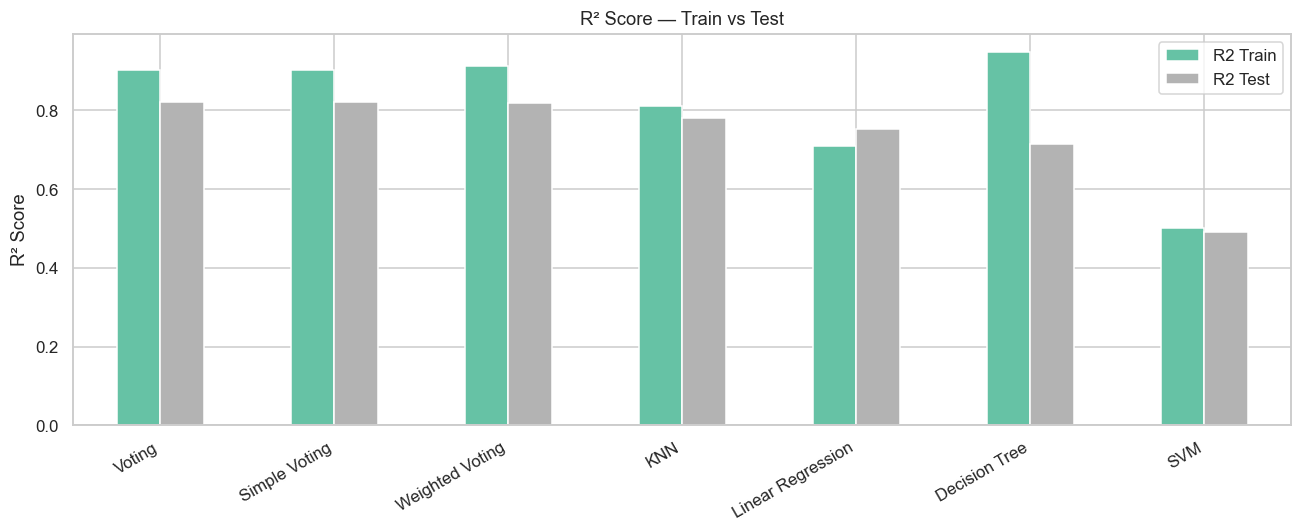

In [26]:
errors_df[["R2 Train", "R2 Test"]].plot.bar(figsize=(12, 5), colormap='Set2', edgecolor='white')
plt.title("R² Score — Train vs Test")
plt.ylabel("R² Score")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


### 7.3 Full Metrics Comparison


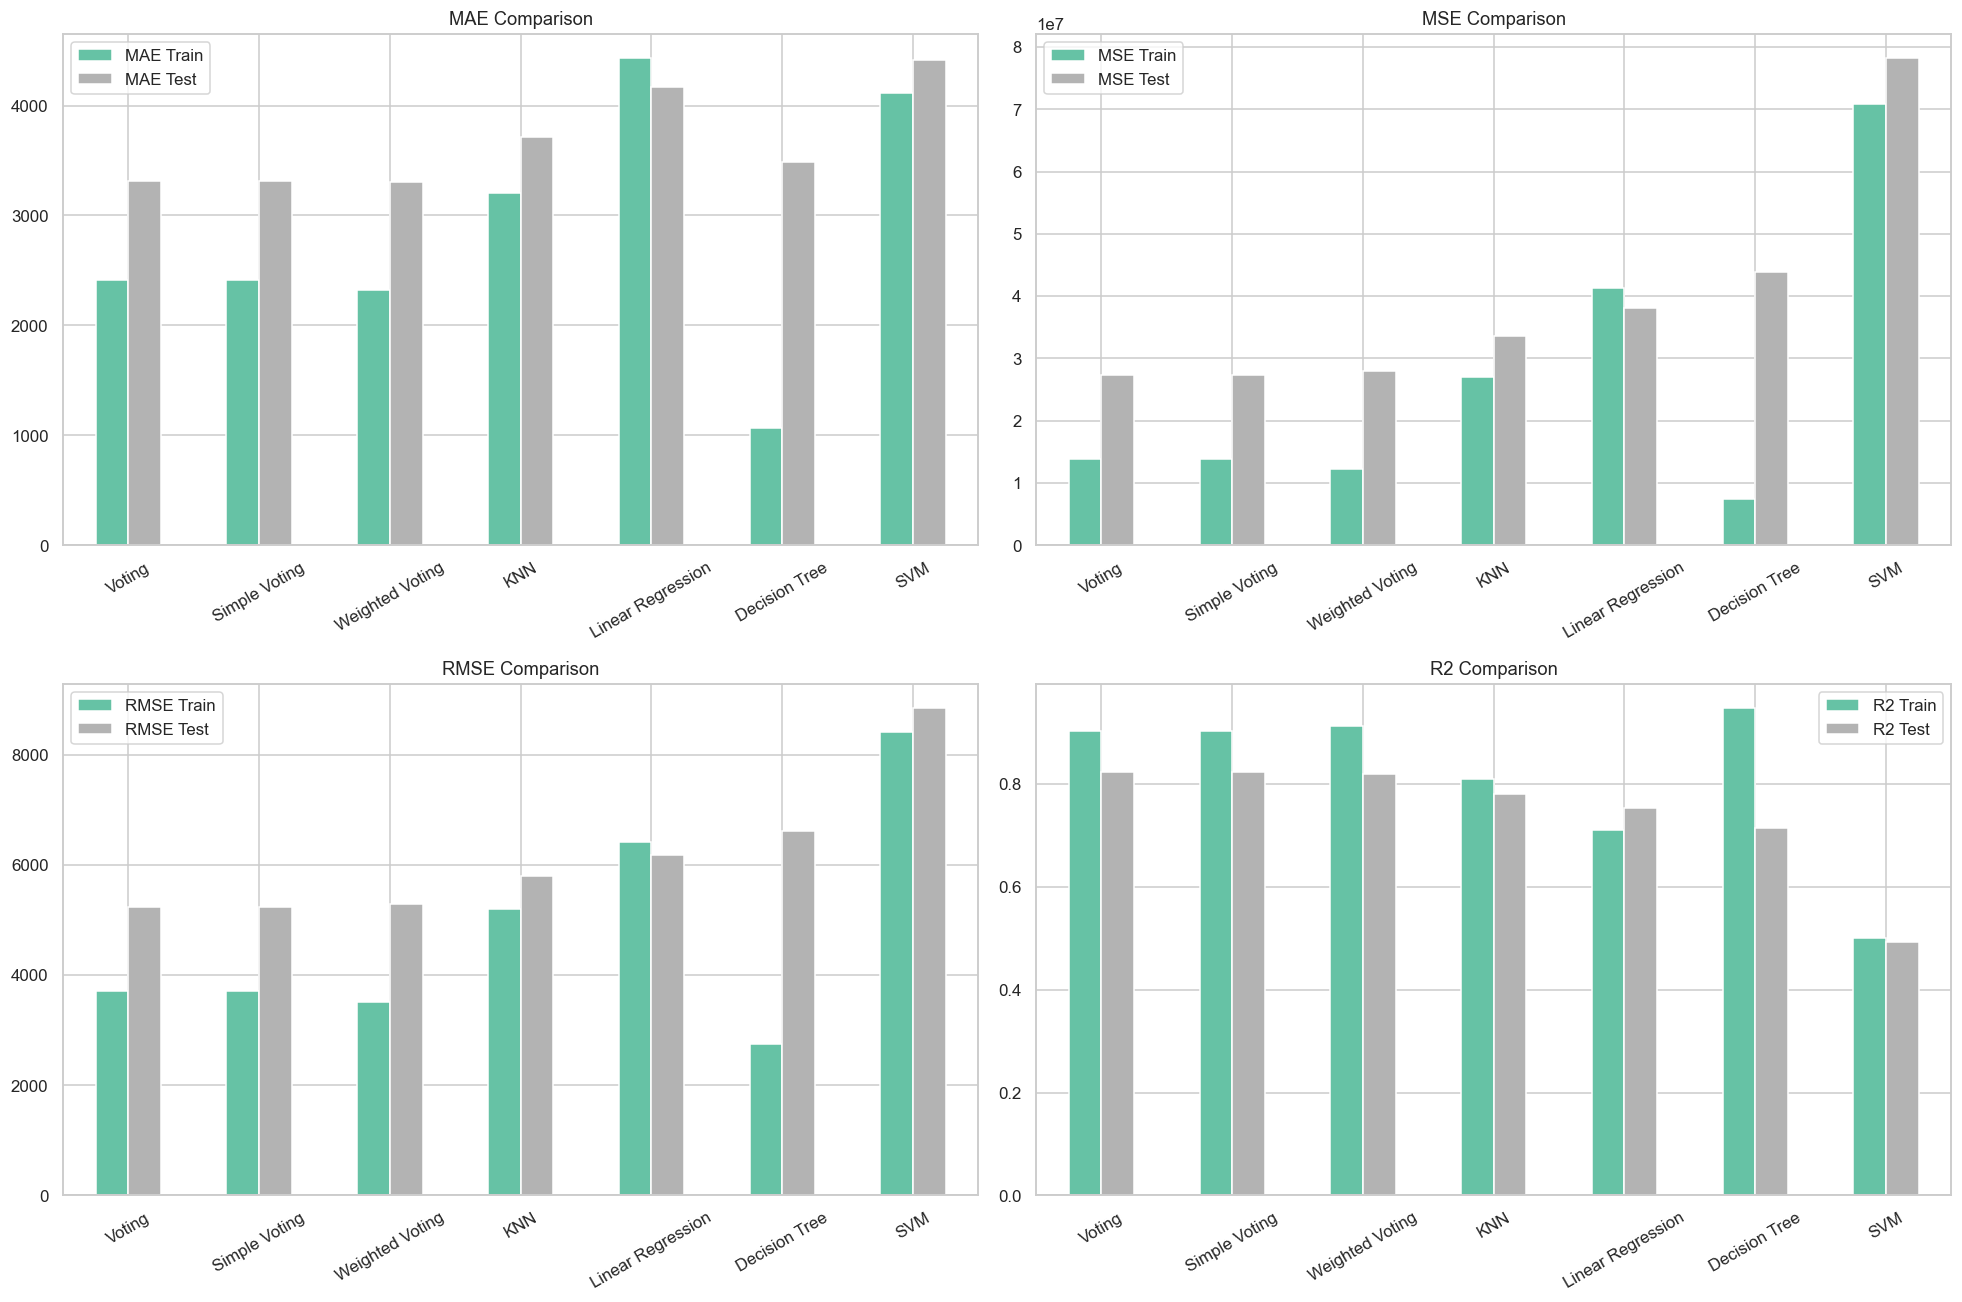

In [27]:
cols = [
    ['MAE Train',  'MAE Test'],
    ['MSE Train',  'MSE Test'],
    ['RMSE Train', 'RMSE Test'],
    ['R2 Train',   'R2 Test']
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, col in zip(axes.flat, cols):
    errors_df[col].plot.bar(ax=ax, colormap='Set2', edgecolor='white')
    ax.set_title(col[0].split()[0] + ' Comparison')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


---
## 8. ✅ Conclusion

| Takeaway | Detail |
|---|---|
| **Best predictor** | `smoker` status dominates — largest correlation with charges |
| **Top model** | Decision Tree (depth=10) & Voting ensembles generally outperform linear models on this dataset |
| **Overfitting watch** | Decision Tree shows a large Train / Test R² gap — consider pruning or Random Forest |
| **Next steps** | Try XGBoost / LightGBM, log-transform the target (`charges`), and use cross-validation |
